# Session 4

## Mini challenge

Your name is Dr. Grace Ryland and you have been tasked as the scientist to save earth on [Project Hail Mary](https://www.google.com/search?q=project+hail+mary&oq=projec&gs_lcrp=EgZjaHJvbWUqDQgAEAAY4wIYsQMYgAQyDQgAEAAY4wIYsQMYgAQyCggBEC4YsQMYgAQyBggCEEUYOTINCAMQLhiDARixAxiABDINCAQQLhjHARjRAxiABDIGCAUQRRg8MgYIBhBFGEEyBggHEEUYPNIBCDQ2MDlqMGo3qAIAsAIA&sourceid=chrome&source=chrome.ob&ie=UTF-8).

However, your new alien buddy [Rocky](https://www.orzgk.com/product/panda-studio-rocky-project-hail-mary/) has mislabelled 10 samples.

It is crucial for earths survival that you can re-identify each participant by their multi-omics profile and the amaze, amaze, amaze, scientific notes you took down prior to rocky's accident.

Using the patient's history below, and the skills you have developed re-identify each sample to the missing patient ids.

Also, thankfully due to some earlier statistics you know that the missing samples consist of 5 luminal A and 5 luminal B subtypes.

Good luck

### How this notebook is organised

1. **Setup** — environment check + imports
2. **Load data** — the 10 mislabelled ("challenge") samples, the labelled training cohort, and a pretrained MOFA multi-omics model
3. **Project** the challenge samples into the MOFA factor space learned from the training cohort
4. **Visualise** the factor space to see where the unknown samples fall relative to known subtypes
5. **Classify** each unknown sample as Luminal A / Luminal B using a simple logistic regression on the factors
6. **Explain** each prediction by finding the genes driving each unknown sample's factor values, then linking those genes to diseases via a knowledge graph — to match against the clinical notes below
7. **Answer** — fill in your final `Pat_i -> TCGA-xxxx` mapping

## Patient clinical notes

Prior to the accident, these are the disease/phenotype notes you recorded for each of the 10 patients whose samples are now mislabelled `Pat_0` ... `Pat_9`. You'll use these — together with the molecular evidence gathered below — to work out which `Pat_i` is which `TCGA-xxxx`.

**TCGA-EW-A6S9** — Presented with invasive breast carcinoma. Immunohistochemistry came back HER2-negative, but strongly positive for both estrogen and progesterone receptors, marking this out as a clearly hormone-receptor-driven tumor.

**TCGA-A2-A0EP** — Biopsy of a breast mass confirmed adenocarcinoma of ductal origin — glandular architecture arising from the mammary ducts, the most textbook presentation of the disease.

**TCGA-E2-A1IG** — A patient managing both asthma and Parkinson disease for several years, whose case took a sharp turn with the diagnosis of breast angiosarcoma, a rare and fast-growing vascular malignancy rather than a typical epithelial breast cancer.

**TCGA-AQ-A1H3** — Decades of type 1 diabetes had already taken a toll by the time she came in: coronary artery disease and chronic kidney disease, the two classic downstream complications of long-standing diabetic vascular damage.

**TCGA-AC-A2FE** — Type 2 diabetes was already on the chart when breast angiosarcoma was diagnosed — a second, unrelated but noteworthy vascular malignancy layered onto an existing metabolic condition.

**TCGA-A2-A1FX** — Screening first picked up lobular neoplasia; further workup of a separate area of the breast then revealed medullary carcinoma, a less common but relatively well-differentiated histological subtype.

**TCGA-A2-A4S3** — Living with multiple sclerosis, this patient went on to develop two independent primary cancers around the same time: an adenocarcinoma of the lung and a colorectal cancer, an unusually heavy cancer burden for one case.

**TCGA-C8-A26W** — Chronic kidney disease was a long-standing issue by the time gastric carcinoma appeared, and the picture was complicated further still by a later diagnosis of acute myeloid leukemia — three serious conditions converging in one patient.

**TCGA-AR-A2LK** — A palpable lump led to biopsy and a diagnosis of ductal adenocarcinoma of the breast, the same core histology as the most common form of breast adenocarcinoma.

**TCGA-AO-A0JD** — Type 2 diabetes was a pre-existing condition when this patient was diagnosed with breast angiosarcoma, a rare vascular tumor of the breast rather than the far more common ductal or lobular types.

## 1. Setup

In [3]:
# Quick environment check (optional).
# Confirms the notebook is running on the expected machine / Python env / folder,
# since path or environment mismatches are a common source of confusing errors.
import socket
import os
import sys

print("Host:", socket.gethostname())
print("Python:", sys.executable)
print("Working dir:", os.getcwd())

Host: kh066
Python: /home/bryan/miniconda3/envs/eccb2026/bin/python
Working dir: /work/gr-fe/bryan/ECCB2026_TEST/sessions/session-4-kg-query-mini-challenge


In [4]:
# ── Standard library ─────────────────────────────────────────────────────────
from pathlib import Path
import pickle

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from matplotlib.colors import TwoSlopeNorm
from IPython.display import display

from sklearn.linear_model import LogisticRegression
# Extra metrics you may want once you've settled on a final answer and want to
# sanity-check a prediction against a partially-known label, or during model
# development on the labelled training cohort:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report

# MOFA (Multi-Omics Factor Analysis): mofax is used to *read* a pretrained model.
# mofapy2 is only needed if you want to *train* a MOFA model from scratch, which
# isn't required for this challenge (a pretrained model is provided below).
import mofax as mfx

# ── Custom helpers for this workshop (see s4_helpers.py) ───────────────────────
from s4_helpers import (
    load_omics,
    evaluate_predictions,
    load_kg,
    print_graph_info,
    map_genes_to_kg,
    diseases_for_genes,
)

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42

## 2. Load data

We need three things:

1. The **10 mislabelled "challenge" samples** (`Pat_0` ... `Pat_9`) — these are the ones we're re-identifying.
2. The **labelled training cohort** used to train the MOFA model, plus the train/test patient ID split that was used at training time.
3. The **pretrained MOFA model** itself, so we can project the challenge samples into the same factor space.

In [5]:
# The 10 mislabelled samples for this challenge.
DATA_DIR = Path(".")

X_challenge_omics, y_challenge = load_omics(
    DATA_DIR,
    omic_filename="challenge_omics",
    omic_keys=["transcriptomics", "proteomics", "methylation"],
)

# The TCGA IDs Rocky mixed up (order not meaningful — this is what we're solving for).
missing_ids = [
    "TCGA-EW-A6S9", "TCGA-A2-A0EP", "TCGA-E2-A1IG",
    "TCGA-AQ-A1H3", "TCGA-AC-A2FE", "TCGA-A2-A1FX",
    "TCGA-A2-A4S3", "TCGA-C8-A26W", "TCGA-AR-A2LK", "TCGA-AO-A0JD",
]
pat_ids = [f"Pat_{i}" for i in range(10)]

# The true subtype of each challenge sample is unknown by construction — that's
# half of what we're inferring (the other half is the exact patient identity).
y_challenge["subtype"] = ["Unknown" for _ in range(10)]
y_challenge = y_challenge[["subtype"]]

# Relabel the challenge cohort with anonymised Pat_0..Pat_9 IDs.
for view in X_challenge_omics:
    X_challenge_omics[view].index = pat_ids
y_challenge.index = pat_ids

X_challenge_omics

Omic view dimensions:
  transcriptomics:   10 patients x  29995 features
  proteomics     :   10 patients x    464 features
  methylation    :   10 patients x 200000 features

Subtype counts:


subtype
Unknown    10
Name: count, dtype: int64

{'transcriptomics':        ENSG00000000003.15  ENSG00000000005.6  ENSG00000000419.13  \
 Pat_0           10.206609           3.890222           10.963447   
 Pat_1           11.227947           7.885052           10.747011   
 Pat_2           10.858597           3.622629           10.543180   
 Pat_3           11.418415           6.649170           10.675950   
 Pat_4           11.639118           7.683469           10.614152   
 Pat_5           10.006381           3.991210           10.967056   
 Pat_6           11.320906           4.597212           11.209474   
 Pat_7           11.521549           4.382121           11.129100   
 Pat_8           11.692278           4.079725           11.140742   
 Pat_9           12.186842           4.716691           11.855058   
 
        ENSG00000000457.14  ENSG00000000460.17  ENSG00000000938.13  \
 Pat_0            9.960213            8.783081            7.883629   
 Pat_1           11.352407            8.963408           11.828274   
 Pat_2    

In [6]:
# The labelled training cohort (TCGA-BRCA) that the MOFA model below was trained on.
TRAIN_DATA_DIR = Path("../../data_tmp/TCGA-BRCA/")

X_omics, y = load_omics(
    TRAIN_DATA_DIR,
    omic_filename="omics",
    omic_keys=["transcriptomics", "proteomics", "methylation"],
)

with open(TRAIN_DATA_DIR / "patient_splits.pkl", "rb") as f:
    splits = pickle.load(f)

train_ids = splits["train_ids"]
test_ids = splits["test_ids"]

# Split the labels using the same patient IDs used for the omics data.
y_train = y.loc[train_ids]
y_test = y.loc[test_ids]

Omic view dimensions:
  transcriptomics:  500 patients x  29995 features
  proteomics     :  500 patients x    464 features
  methylation    :  500 patients x 200000 features

Subtype counts:


paper_BRCA_Subtype_PAM50
LumA      237
LumB      100
Basal      97
Her2       41
Normal     25
Name: count, dtype: int64

In [7]:
# Load the pretrained MOFA model.
mofa_model_mfx = mfx.mofa_model("mofa_pretrained.hdf5")

print(mofa_model_mfx)          # Model overview
print(mofa_model_mfx.shape)    # (n_samples, n_factors)

# Extract key components.
factors = mofa_model_mfx.get_factors(df=True)               # Factor/latent space values
weights = mofa_model_mfx.get_weights(df=True)         # Feature weights/loadings
var_exp = mofa_model_mfx.get_variance_explained()     # R^2 per factor per view

# NOTE: the exact factor-name format (e.g. "Factor1" vs "Factor 1") depends on
# your mofax version. Check this before relying on either format later in the
# notebook:
print("Factor column names look like:", list(factors.columns[:3]))

MOFA+ model: mofa pretrained
Samples (cells): 375
Features: 4464
Groups: TCGA-BRCA_train (375)
Views: methylation (2000), proteomics (464), transcriptomics (2000)
Factors: 10
Expectations: W, Z
(375, 4464)
Factor column names look like: ['Factor1', 'Factor2', 'Factor3']


## 3. Project the challenge samples into the MOFA factor space

MOFA was fit on the training cohort only. To place the 10 unknown challenge
samples on the same latent axes, we need to *project* them using the feature
weights the model already learned — without ever touching the (unknown) labels.

In [8]:
# Restrict each omics view to the features MOFA actually used (its most-variable,
# training-selected feature set), so train and test matrices line up column-for-column.
X_train_raw = {name: X.loc[train_ids] for name, X in X_omics.items()}
X_test_raw = {name: X for name, X in X_challenge_omics.items()}

features_in_mofa = set(weights.index)
X_train_omics = {}
X_test_omics = {}

for name, X_train_view in X_train_raw.items():
    selected_features = list(features_in_mofa & set(X_train_view.columns))
    X_train_omics[name] = X_train_view.loc[:, selected_features]
    X_test_omics[name] = X_test_raw[name].loc[:, selected_features]

print("Feature counts after filtering to MOFA's feature set:")
for name in X_omics:
    print(
        f"  {name:15s}: {X_omics[name].shape[1]:6d} original -> "
        f"{X_train_omics[name].shape[1]:6d} used by MOFA"
    )

Feature counts after filtering to MOFA's feature set:
  transcriptomics:  29995 original ->   2000 used by MOFA
  proteomics     :    464 original ->    464 used by MOFA
  methylation    : 200000 original ->   2000 used by MOFA


In [9]:
def project_test_patients_to_mofa_factors(model, X_train_by_view, X_test_by_view, train_factors, view_names):
    """Project held-out patients into the fixed MOFA factor space.

    The projection uses MOFA weights learned from training patients. To keep
    train and test factor values comparable, preprocessing and calibration are
    fit on training patients only and then applied unchanged to test patients
    (test labels are never used anywhere in this function).
    """
    factor_columns = train_factors.columns.astype(str).tolist()
    projected_test_by_view = []

    for view_name in view_names:
        # W is the learned feature x factor weight matrix for this omics view.
        view_weights = model.get_weights(views=view_name, df=True)
        view_weights.columns = view_weights.columns.astype(str)
        view_weights = view_weights.reindex(columns=factor_columns)

        # Use only features present in the trained weights AND both train/test matrices.
        common_features = view_weights.index.intersection(X_train_by_view[view_name].columns)
        common_features = common_features.intersection(X_test_by_view[view_name].columns)
        view_weights = view_weights.loc[common_features]

        X_train_view = X_train_by_view[view_name].loc[:, common_features].astype(float)
        X_test_view = X_test_by_view[view_name].loc[:, common_features].astype(float)
        X_train_view.index = X_train_view.index.astype(str)
        X_test_view.index = X_test_view.index.astype(str)

        # Learn centering/scaling on training patients only, then apply it to test patients.
        train_mean = X_train_view.mean(axis=0)
        train_std = X_train_view.std(axis=0, ddof=0).replace(0, 1)
        X_train_scaled = (X_train_view - train_mean) / train_std
        X_test_scaled = (X_test_view - train_mean) / train_std

        # Project X into the fixed MOFA weight space via the pseudo-inverse of W.
        raw_train_projection = X_train_scaled.to_numpy() @ np.linalg.pinv(view_weights.to_numpy()).T
        raw_test_projection = X_test_scaled.to_numpy() @ np.linalg.pinv(view_weights.to_numpy()).T

        # Calibrate the raw projection to the factor scale returned by the trained
        # MOFA model. Fitted on training patients only; test labels are never used.
        train_design = np.column_stack([raw_train_projection, np.ones(raw_train_projection.shape[0])])
        test_design = np.column_stack([raw_test_projection, np.ones(raw_test_projection.shape[0])])
        train_target = train_factors.loc[X_train_view.index, factor_columns].to_numpy()
        calibration = np.linalg.lstsq(train_design, train_target, rcond=None)[0]
        projected_values = test_design @ calibration

        projected = pd.DataFrame(projected_values, index=X_test_view.index, columns=factor_columns)
        projected_test_by_view.append(projected)

    # Each view gives one projected factor table; average them since all views
    # are available for every challenge sample here.
    return sum(projected_test_by_view) / len(projected_test_by_view)

In [10]:
# Extract training-patient factor values straight from the fitted MOFA model.
train_factors_mfx = mofa_model_mfx.get_factors(df=True)
train_factors_mfx.index = train_factors_mfx.index.astype(str)

# Project the 10 held-out challenge patients into that same factor space.
test_factors_mfx = project_test_patients_to_mofa_factors(
    mofa_model_mfx,
    X_train_omics,
    X_test_omics,
    train_factors_mfx,
    list(X_train_omics.keys()),
)

In [11]:
# Attach the known training subtypes to the model so mofax's built-in plots can
# colour training points by subtype.
mofa_sample_metadata = pd.DataFrame(index=train_factors_mfx.index)
mofa_sample_metadata["subtype"] = y_train.reindex(train_factors_mfx.index).values

mofa_model_mfx.samples_metadata = mofa_sample_metadata

## 4. Visualise the factor space

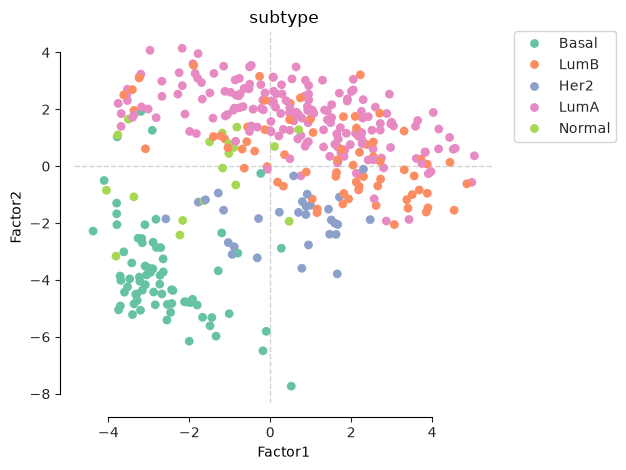

In [12]:
# Built-in mofax scatter grid, training patients only, coloured by subtype.
mfx.plot_factors_scatter(
    mofa_model_mfx,
    x="Factor1",
    y="Factor2",
    group_label="subtype",
    color="subtype",
    zero_line_x=True,
    zero_line_y=True,
    ncols=3,
    size=40,
    alpha=1,
)
plt.show()

In [13]:
# Combine training (known subtype) and challenge (unknown subtype) factors into
# one long table we can reuse for every plot below.
plot_df = pd.concat([train_factors_mfx, test_factors_mfx])

subtypes_col = pd.concat([
    y_train,
    pd.Series(["Unknown"] * len(test_factors_mfx), index=test_factors_mfx.index),
])
plot_df["subtype"] = subtypes_col

plot_df

,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10,subtype
TCGA-S3-AA0Z,-2.677049,-4.491632,1.438483,-0.422795,0.741272,1.235917,1.497584,-0.306961,0.952876,-0.117106,Basal
TCGA-E9-A1N6,0.180977,-0.561914,-3.574715,-2.498562,-3.337365,-2.594017,-1.536899,1.478458,-0.399653,1.112885,LumB
TCGA-C8-A26Y,-1.037958,-2.685832,0.221065,-2.129348,-1.283929,-3.698094,-2.550864,3.238068,0.323258,0.714914,Her2
TCGA-A7-A0D9,0.757382,-0.338205,-1.839327,6.520308,-4.192802,1.799493,-0.594609,1.617057,-4.788059,2.172852,LumA
TCGA-A2-A0CT,4.982207,-0.566879,0.930730,-0.789196,-1.455145,2.251426,3.763444,1.592921,0.738021,0.874641,LumA
...,...,...,...,...,...,...,...,...,...,...,...
Pat_5,1.732713,1.484934,0.798178,-0.922396,-0.938942,2.177108,-1.136659,0.900399,-0.561686,-0.393969,Unknown
Pat_6,0.525045,-0.649719,0.079504,-1.348195,1.465892,0.453576,-1.885745,0.881061,-0.181360,0.944625,Unknown
Pat_7,-0.511048,1.179021,-1.281183,-0.298532,0.825806,-0.048020,-1.702661,-0.368831,0.132252,0.810454,Unknown
Pat_8,2.410831,1.197439,1.041670,-1.269500,-0.668765,0.721102,0.172933,-1.027378,-0.076351,0.376981,Unknown


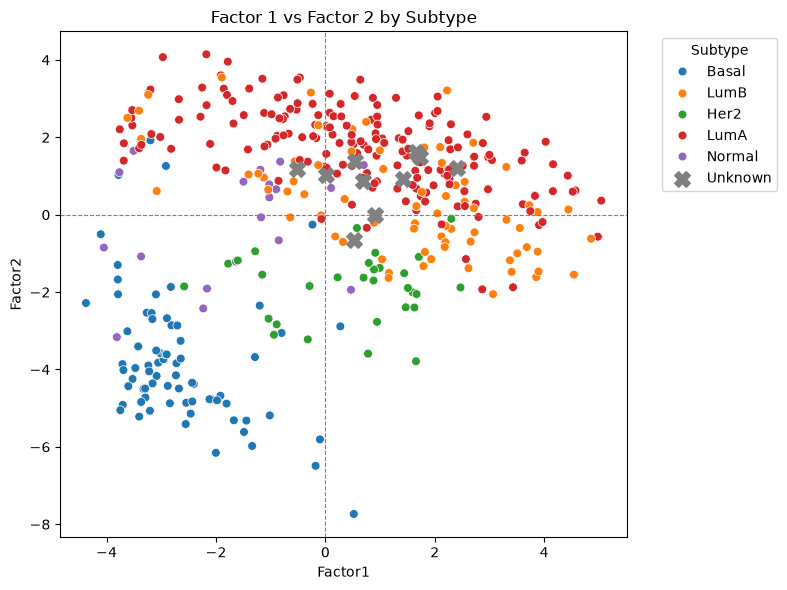

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

# Split known vs unknown subtypes (handles both NaN and the literal 'Unknown' label).
known = plot_df[plot_df["subtype"].notna() & ~plot_df["subtype"].isin(["Unknown"])]
unknown = plot_df[plot_df["subtype"].isna() | plot_df["subtype"].isin(["Unknown"])]

# Known subtypes as coloured circles.
sns.scatterplot(data=known, x="Factor1", y="Factor2", hue="subtype", s=40, alpha=1, ax=ax)

# Unknown (challenge) samples as bigger grey crosses, drawn on top.
ax.scatter(
    unknown["Factor1"], unknown["Factor2"],
    marker="X", s=120, color="grey", label="Unknown", zorder=5, linewidths=1.2,
)

ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Factor 1 vs Factor 2 by Subtype")
ax.legend(title="Subtype", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 4.1 Compare subtypes across a wider set of factors

Two factors aren't always enough to separate every subtype — below we look at a
few more factors as boxplots (by known subtype) and then as individual scatter
points for the unknown samples, so we can eyeball which subtype each challenge
sample is likely to belong to before formally classifying it in Section 5.

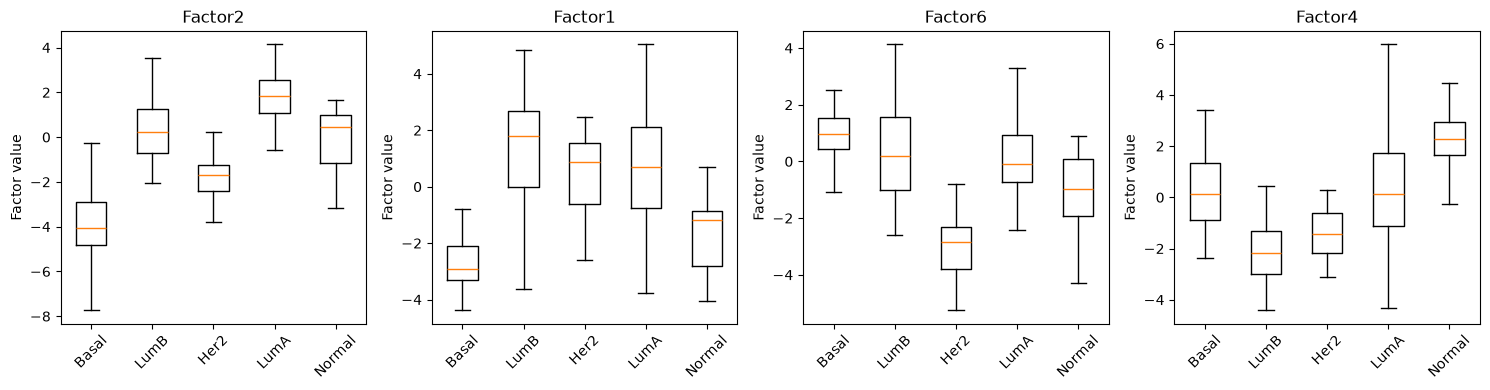

In [15]:
subtype_order = ["Basal", "LumB", "Her2", "LumA", "Normal"]
factors_of_interest = ["Factor2", "Factor1", "Factor6", "Factor4"]

fig, axes = plt.subplots(1, len(factors_of_interest), figsize=(15, 4), squeeze=False)

for ax, factor in zip(axes.ravel(), factors_of_interest):
    groups = [
        plot_df.loc[plot_df["subtype"] == subtype, factor].dropna()
        for subtype in subtype_order
    ]
    ax.boxplot(groups, tick_labels=subtype_order, showfliers=False)
    ax.set_title(factor)
    ax.set_ylabel("Factor value")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

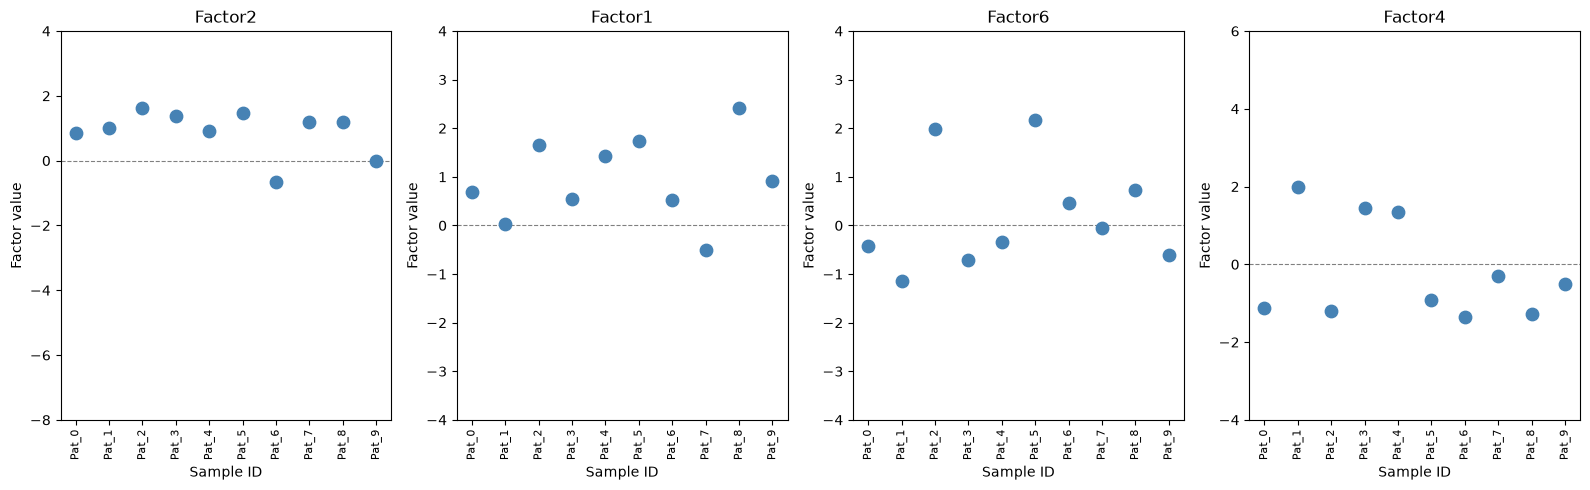

In [16]:
# Y-axis limits per factor, just for a bit of visual polish.
ylims = {
    "Factor2": (-8, 4),
    "Factor1": (-4, 4),
    "Factor6": (-4, 4),
    "Factor4": (-4, 6),
}

unknown_df = plot_df[plot_df["subtype"] == "Unknown"]

fig, axes = plt.subplots(1, len(factors_of_interest), figsize=(16, 5), squeeze=False)

for ax, factor in zip(axes.ravel(), factors_of_interest):
    vals = unknown_df[factor].dropna()

    ax.scatter(range(len(vals)), vals.values, s=80, color="steelblue", zorder=5)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=90, fontsize=8)
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_ylim(ylims[factor])
    ax.set_title(factor)
    ax.set_ylabel("Factor value")
    ax.set_xlabel("Sample ID")

plt.tight_layout()
plt.show()

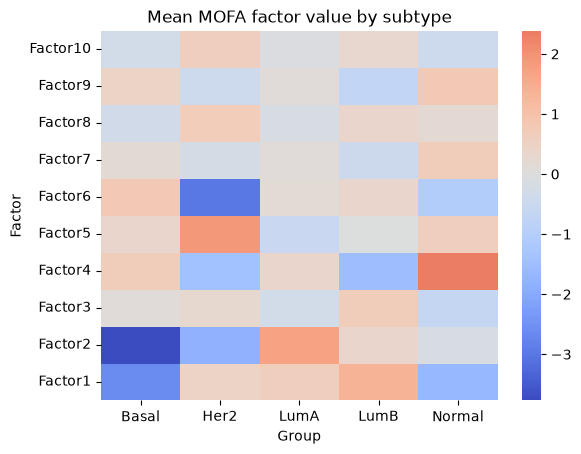

In [17]:
# Built-in mofax heatmap of the mean factor value per subtype (training patients only —
# challenge patients have subtype == NaN/'Unknown' so they don't contribute here).
mfx.plot_factors_matrix(
    mofa_model_mfx,
    group_label="subtype",
    cmap="coolwarm",
    center=0,
)
plt.title("Mean MOFA factor value by subtype")
plt.show()

/tmp/4124673/ipykernel_920994/1113544594.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


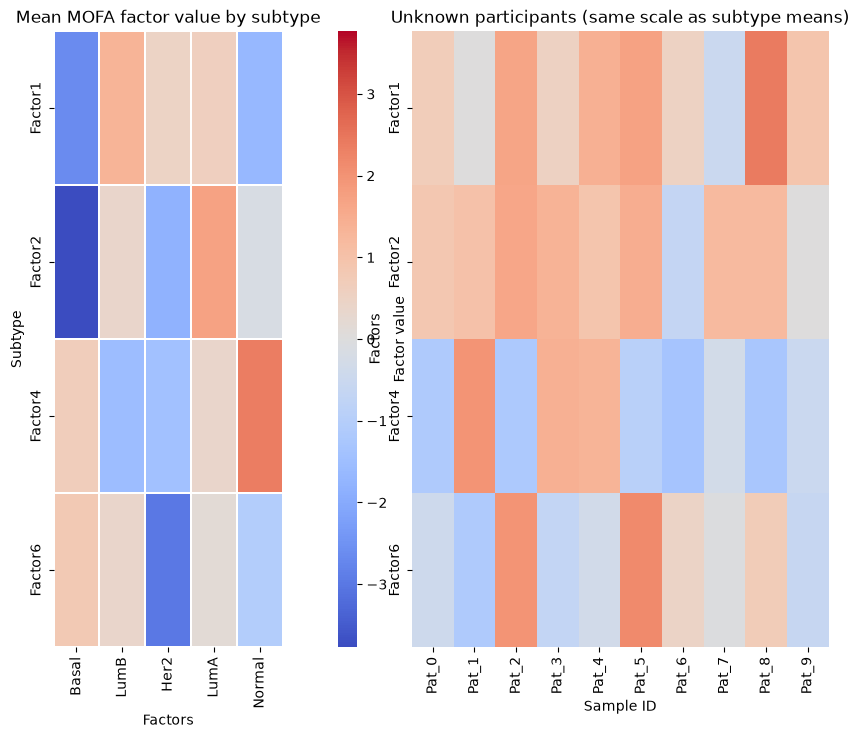

In [18]:
# Recreate that same subtype-mean heatmap side-by-side with the unknown samples,
# on a shared colour scale, so it's easy to visually match each unknown sample's
# row-pattern to the subtype it most resembles.
heatmap_factors = [f"Factor{i}" for i in [1, 2, 4, 6]]

unknown_mask = plot_df["subtype"].isna() | plot_df["subtype"].isin(["Unknown", "NA", "unknown"])

unknown_mat = plot_df.loc[unknown_mask, heatmap_factors].dropna(how="all")
heat_unknown = unknown_mat.T  # rows = factors, cols = sample IDs

means_by_subtype = (
    plot_df.loc[~unknown_mask, ["subtype"] + heatmap_factors]
    .dropna(subset=["subtype"])
    .groupby("subtype")[heatmap_factors]
    .mean()
    .reindex(subtype_order)
)

# Colour scale is defined ONLY from the subtype-mean matrix, so the unknown
# heatmap is shown on the exact same scale as the reference panel.
vmax = np.nanmax(np.abs(means_by_subtype.values))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

fig = plt.figure(figsize=(max(10, 0.35 * heat_unknown.shape[1] + 6), 8))
gs = fig.add_gridspec(1, 3, width_ratios=[2.2, 0.18, max(4, 0.35 * heat_unknown.shape[1])], wspace=0.25)

ax_ref = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])
ax_unk = fig.add_subplot(gs[0, 2])

sns.heatmap(means_by_subtype.T, ax=ax_ref, cmap="coolwarm", norm=norm, cbar=False,
            linewidths=0.2, linecolor="white")
ax_ref.set_title("Mean MOFA factor value by subtype")
ax_ref.set_xlabel("Factors")
ax_ref.set_ylabel("Subtype")
ax_ref.tick_params(axis="x", rotation=90)

sns.heatmap(heat_unknown, ax=ax_unk, cmap="coolwarm", norm=norm, cbar=True,
            cbar_ax=cax, linewidths=0.0)
ax_unk.set_title("Unknown participants (same scale as subtype means)")
ax_unk.set_xlabel("Sample ID")
ax_unk.set_ylabel("Factors")
ax_unk.tick_params(axis="x", rotation=90)

cax.set_ylabel("Factor value")
plt.tight_layout()
plt.show()

## 5. Classify each unknown sample: Luminal A or Luminal B

We already know (from earlier statistics) that all 10 unknown samples are
either Luminal A or Luminal B. A simple logistic regression on the MOFA
factors — trained on the labelled cohort — gives us a first, quantitative
pass at this split, which we can combine with the visual read from Section 4.

In [19]:
# 1) Get y_train as a 1D Series of subtype labels.
subtype_labels = y_train
if isinstance(subtype_labels, pd.DataFrame):
    if "paper_BRCA_Subtype_PAM50" in subtype_labels.columns:
        subtype_labels = subtype_labels["paper_BRCA_Subtype_PAM50"]
    elif "subtype" in subtype_labels.columns:
        subtype_labels = subtype_labels["subtype"]
    else:
        raise ValueError("Could not find a subtype column in y_train.")

# 2) Align train X and y by sample IDs.
common_ids = train_factors_mfx.index.intersection(subtype_labels.index)
X_train_clf = train_factors_mfx.loc[common_ids]
y_train_clf = subtype_labels.loc[common_ids]

# 3) Fit a simple multi-class logistic regression on all factors.
clf = LogisticRegression(solver="lbfgs", max_iter=5000, random_state=RANDOM_STATE)
clf.fit(X_train_clf, y_train_clf)

# 4) Predict on the challenge (unknown) samples.
test_pred = clf.predict(test_factors_mfx)
predicted_subtype = pd.Series(test_pred, index=test_factors_mfx.index, name="predicted_subtype")

predicted_subtype

Pat_0    LumA
Pat_1    LumA
Pat_2    LumA
Pat_3    LumA
Pat_4    LumA
Pat_5    LumA
Pat_6    LumB
Pat_7    LumA
Pat_8    LumA
Pat_9    LumB
Name: predicted_subtype, dtype: object

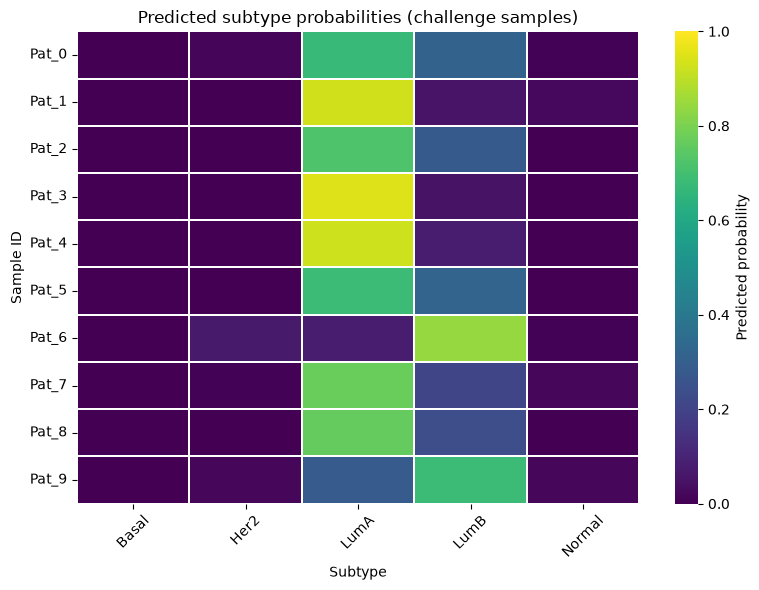

,Basal,Her2,LumA,LumB,Normal
Pat_0,3.847440e-05,0.013562,0.671983,0.310265,0.004151
Pat_1,2.466155e-04,0.000998,0.926213,0.051993,0.020549
Pat_2,2.847282e-07,0.000012,0.719408,0.280566,0.000013
Pat_3,2.101006e-05,0.000099,0.947450,0.049191,0.003239
Pat_4,1.386258e-05,0.000172,0.923490,0.074452,0.001872
Pat_5,4.128784e-07,0.000006,0.683015,0.316967,0.000012
Pat_6,2.432563e-03,0.068885,0.081754,0.841215,0.005713
Pat_7,3.578692e-04,0.004467,0.770673,0.206939,0.017563
Pat_8,4.269855e-07,0.000212,0.761841,0.237774,0.000172
Pat_9,1.166027e-03,0.016971,0.281572,0.682959,0.017332


In [20]:
predicted_proba = pd.DataFrame(
    clf.predict_proba(test_factors_mfx),
    index=test_factors_mfx.index,
    columns=clf.classes_,
)

fig, ax = plt.subplots(figsize=(8, max(6, 0.25 * predicted_proba.shape[0])))

sns.heatmap(
    predicted_proba,
    cmap="viridis",
    vmin=0, vmax=1,
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"label": "Predicted probability"},
    ax=ax,
)
ax.set_title("Predicted subtype probabilities (challenge samples)")
ax.set_xlabel("Subtype")
ax.set_ylabel("Sample ID")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

predicted_proba

## 6. Explain each unknown sample: driving genes -> diseases

Knowing Luminal A vs B narrows things down but doesn't tell us *which*
patient a sample belongs to. For that we look at which genes most strongly
drive each unknown sample's position in factor space, then look up which
diseases those genes are associated with in a knowledge graph — so we can
match against the clinical notes at the top of the notebook.

We run this for **all 10** unknown samples (not just one), since we need to
resolve every `Pat_i`.

In [21]:
def top_features_weighted_by_expression(
    model,
    X: pd.DataFrame,
    sample_id: str,
    factor: str,
    view: str,
    top_n: int = 20,
    standardize: bool = True,
):
    """Rank features for one sample/factor by |weight| * |expression|.

    A feature's contribution to a sample's factor value is roughly proportional
    to its MOFA weight times how far that sample's (standardized) expression is
    from the cohort mean. Sorting by this product surfaces the genes that most
    plausibly explain *why* this particular sample sits where it does on this factor.
    """
    # W: features x factors
    W = model.get_weights(views=view, df=True)
    w = W[factor]

    x = X.loc[sample_id]
    if standardize:
        # z-score each feature across samples so weight and expression are comparable.
        x = (x - X.mean(axis=0)) / X.std(axis=0).replace(0, pd.NA)

    impact = (w.abs() * x.abs()).dropna().sort_values(ascending=False)

    out = pd.DataFrame({
        "weight_abs": w.abs().reindex(impact.index),
        "x_abs": x.abs().reindex(impact.index),
        "impact": impact,
    })
    return out.head(top_n)

In [22]:
# Which factors and view to explain each sample with. Factor1/2/4/6 were the
# ones that visually separated subtypes best in Section 4 — feel free to widen
# this set (or try 'proteomics'/'methylation') if your matches aren't conclusive.
factors_to_explain = ["Factor1", "Factor2", "Factor4", "Factor6"]
view = "transcriptomics"

# top_genes_by_sample: {sample_id -> list of top driving gene names}
top_genes_by_sample = {}

for sample_id in unknown_df.index:
    genes_for_this_sample = []
    for factor in factors_to_explain:
        top = top_features_weighted_by_expression(
            mofa_model_mfx,
            X_test_omics[view],
            sample_id=sample_id,
            factor=factor,
            view=view,
            top_n=25,
        )
        genes_for_this_sample += list(top.index)
    top_genes_by_sample[sample_id] = sorted(set(genes_for_this_sample))

for sample_id, genes in top_genes_by_sample.items():
    print(f"{sample_id}: {len(genes)} candidate driving genes")

Pat_0: 84 candidate driving genes
Pat_1: 89 candidate driving genes
Pat_2: 85 candidate driving genes
Pat_3: 91 candidate driving genes
Pat_4: 82 candidate driving genes
Pat_5: 85 candidate driving genes
Pat_6: 83 candidate driving genes
Pat_7: 78 candidate driving genes
Pat_8: 85 candidate driving genes
Pat_9: 83 candidate driving genes


In [23]:
# Load the gene-disease knowledge graph once.
G = load_kg()
print_graph_info(G)

Number of nodes: 881
Number of edges: 1768
Graph type: undirected

Nodes by type:
     760  gene
      90  disease
      31  icd10
Edges by type:
   1,656  associated_with
      81  is_a
      31  maps_to

Self-loops: 0
Graph density: 0.004561
Connected components: 1
Largest component: 881 nodes (100.0% of the graph)
Average clustering coefficient: 0.0137


In [24]:
# For each unknown sample, map its driving genes onto the KG and pull the
# diseases most associated with them — these are the clues to match against
# the clinical notes at the top of the notebook.
disease_hits_by_sample = {}

for sample_id, genes in top_genes_by_sample.items():
    mapped = map_genes_to_kg(G, genes)
    n_in_kg = mapped["in_kg"].sum()

    diseases = diseases_for_genes(G, genes, top_n=30)
    disease_hits_by_sample[sample_id] = diseases

    print(f"\n=== {sample_id}: {n_in_kg} / {len(mapped)} genes found in KG ===")
    display(diseases.head(10))


=== Pat_0: 8 / 84 genes found in KG ===


,disease_id,name,n_genes,mean_score,genes
0,MONDO_0006512,estrogen-receptor positive breast cancer,4,0.342725,"ARHGEF38, CCDC170, ESR1, NEK10"
1,MONDO_0000618,Her2-receptor negative breast cancer,4,0.237250,"CCDC170, DNER, ESR1, NEK10"
2,MONDO_0006513,estrogen-receptor negative breast cancer,3,0.305100,"CCDC170, ESR1, NEK10"
3,MONDO_0007254,breast cancer,2,0.681400,"ERBB2, ESR1"
4,MONDO_0004950,gastric carcinoma,2,0.432450,"ERBB2, ESR1"
5,MONDO_0004989,breast carcinoma,2,0.704800,"ERBB2, ESR1"
6,MONDO_0006244,HER2 positive breast carcinoma,2,0.541300,"ERBB2, ESR1"
7,MONDO_0021115,luminal B breast carcinoma,2,0.373450,"CCDC170, ESR1"
8,MONDO_0004988,breast adenocarcinoma,2,0.581300,"ERBB2, ESR1"
9,MONDO_0005298,osteoporosis,2,0.567900,"CCDC170, ESR1"



=== Pat_1: 8 / 89 genes found in KG ===


,disease_id,name,n_genes,mean_score,genes
0,MONDO_0021115,luminal B breast carcinoma,3,0.331667,"ESR1, FOXA1, GATA3"
1,MONDO_0004988,breast adenocarcinoma,3,0.548900,"ESR1, FOXA1, GATA3"
2,MONDO_0006116,breast carcinoma by gene expression profile,3,0.370000,"ESR1, FOXA1, GATA3"
3,MONDO_0005590,breast ductal adenocarcinoma,3,0.379933,"ESR1, FOXA1, GATA3"
4,MONDO_0005298,osteoporosis,2,0.577850,"ESR1, PGR"
5,MONDO_0000552,breast lobular carcinoma,2,0.379500,"ESR1, FOXA1"
6,EFO_0009782,progesterone-receptor positive breast cancer,2,0.178700,"ESR1, THSD4"
7,MONDO_0005063,medullary breast carcinoma,2,0.139350,"ESR1, MUC16"
8,MONDO_0004379,female breast carcinoma,2,0.324100,"ESR1, GATA3"
9,MONDO_0000618,Her2-receptor negative breast cancer,2,0.313500,"ESR1, THSD4"



=== Pat_2: 4 / 85 genes found in KG ===


...

,disease_id,name,n_genes,mean_score,genes
0,MONDO_0007254,breast cancer,1,0.6138,TOP2A
1,MONDO_0008170,ovarian cancer,1,0.5534,TOP2A
2,MONDO_0004988,breast adenocarcinoma,1,0.3787,TOP2A
3,MONDO_0006804,inflammatory breast carcinoma,1,0.2988,TOP2A
4,MONDO_0006256,invasive breast carcinoma,1,0.2895,TOP2A
5,MONDO_0005023,ductal breast carcinoma in situ,1,0.2668,TOP2A
6,MONDO_0006116,breast carcinoma by gene expression profile,1,0.2775,NTRK3
7,MONDO_0005051,invasive lobular breast carcinoma,1,0.0833,NTRK3
8,MONDO_0005300,chronic kidney disease,1,0.5778,AGTR1
9,MONDO_0005090,schizophrenia,1,0.5300,GPM6A



=== Pat_8: 5 / 85 genes found in KG ===


,disease_id,name,n_genes,mean_score,genes
0,MONDO_0005298,osteoporosis,2,0.57785,"ESR1, PGR"
1,MONDO_0021115,luminal B breast carcinoma,2,0.35875,"ESR1, FOXA1"
2,MONDO_0004988,breast adenocarcinoma,2,0.53955,"ESR1, FOXA1"
3,MONDO_0000552,breast lobular carcinoma,2,0.37950,"ESR1, FOXA1"
4,MONDO_0006513,estrogen-receptor negative breast cancer,2,0.34155,"ESR1, OSR1"
5,MONDO_0005590,breast ductal adenocarcinoma,2,0.38335,"ESR1, FOXA1"
6,MONDO_0006116,breast carcinoma by gene expression profile,2,0.37000,"ESR1, FOXA1"
7,MONDO_0004989,breast carcinoma,1,0.71190,ESR1
8,MONDO_0006244,HER2 positive breast carcinoma,1,0.46140,ESR1
9,MONDO_0005628,male breast carcinoma,1,0.42640,ESR1



=== Pat_9: 3 / 83 genes found in KG ===


,disease_id,name,n_genes,mean_score,genes
0,MONDO_0003024,breast angiosarcoma,2,0.09795,"MMP7, PIGR"
1,MONDO_0005148,type 2 diabetes mellitus,1,0.85660,ABCC8


## 7. Your answer: match each sample to a patient

Using:

- the predicted **Luminal A / Luminal B** subtype for each sample (Section 5), and
- the **top associated diseases** for each sample (Section 6),

match each of `Pat_0` ... `Pat_9` to one of the 10 `TCGA-xxxx` IDs from the
clinical notes at the top of this notebook. Every ID should be used exactly once,
and your final answer should contain 5 Luminal A and 5 Luminal B matches.

In [25]:
# TODO: fill this in with your final answer, e.g. {"Pat_0": "TCGA-EW-A6S9", ...}
sample_to_patient = {pat_id: None for pat_id in pat_ids}

sample_to_patient

{'Pat_0': None,
 'Pat_1': None,
 'Pat_2': None,
 'Pat_3': None,
 'Pat_4': None,
 'Pat_5': None,
 'Pat_6': None,
 'Pat_7': None,
 'Pat_8': None,
 'Pat_9': None}

In [26]:
# Sanity checks before you submit.
assert all(v is not None for v in sample_to_patient.values()), "Every Pat_i needs a match."
assert set(sample_to_patient.values()) == set(missing_ids), "Every TCGA ID should be used exactly once."

n_luma = (predicted_subtype.reindex(sample_to_patient.keys()) == "LumA").sum()
n_lumb = (predicted_subtype.reindex(sample_to_patient.keys()) == "LumB").sum()
print(f"Predicted split among your matches -> LumA: {n_luma}, LumB: {n_lumb} (expect 5 / 5)")

# Uncomment once you're happy with your answer:
# evaluate_predictions(sample_to_patient)

AssertionError: Every Pat_i needs a match.